# Image Dataset Preprocessing

This notebook recursively reads images from a source dataset folder such as `rawDatasets/Fantasy` and writes a flattened processed dataset folder such as `processedDatasets/Fantasy`.

Each output image is:
- WebP
- RGB only, with no alpha/transparency channel
- Exactly `192 x 256`
- Resized to preserve the full original height at 256 px
- Center-cropped horizontally if wider than 192 px after resizing
- White-padded horizontally if narrower than 192 px after resizing


In [8]:
from pathlib import Path
from PIL import Image, ImageOps, UnidentifiedImageError
import hashlib
import shutil
from collections import Counter

# Pillow sometimes warns/errors on very large images. Keep this unless you trust all inputs.
# Image.MAX_IMAGE_PIXELS = None


## Configuration

Set `DATASET_NAME` to the folder name inside `rawDatasets`.


In [9]:
DATASET_NAME = "Fantasy"

SOURCE_ROOT = Path("rawDatasets") / DATASET_NAME
OUTPUT_ROOT = Path("processedDatasets") / f"{DATASET_NAME}-512x384"

TARGET_WIDTH = 192 * 2
TARGET_HEIGHT = 256 * 2

# Set to True to delete and recreate the processed dataset folder on each run.
OVERWRITE_OUTPUT_DIR = True

# WebP quality. Use 100 for less compression, or lossless=True in save_webp_kwargs below.
save_webp_kwargs = {
    "quality": 95,
    "method": 6,
}

SOURCE_ROOT, OUTPUT_ROOT


(PosixPath('rawDatasets/Fantasy'),
 PosixPath('processedDatasets/Fantasy-512x384'))

## Helper functions


In [10]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif", ".tif", ".tiff",
    ".ppm", ".pgm", ".pbm", ".pnm", ".jfif", ".avif",
}


def is_candidate_image(path: Path) -> bool:
    """Return True for files that are likely images based on extension."""
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


def make_stable_output_name(path: Path, source_root: Path, index: int) -> str:
    """
    Create a flat, arbitrary-but-stable WebP filename.
    The hash uses the file's relative path, so duplicate basenames do not collide.
    """
    rel = path.relative_to(source_root).as_posix()
    digest = hashlib.sha1(rel.encode("utf-8")).hexdigest()[:16]
    return f"{index:08d}_{digest}.webp"


def open_as_rgb_on_white(path: Path) -> Image.Image:
    """
    Open an image, apply EXIF orientation, and return an RGB image.
    If the source has transparency, composite it onto a white background.
    """
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)

    # For animated GIF/WebP/etc., use the first frame.
    try:
        img.seek(0)
    except EOFError:
        pass

    # Convert transparency to white instead of dropping alpha onto black.
    has_alpha = img.mode in {"RGBA", "LA"} or (img.mode == "P" and "transparency" in img.info)
    if has_alpha:
        rgba = img.convert("RGBA")
        white_bg = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
        composed = Image.alpha_composite(white_bg, rgba)
        return composed.convert("RGB")

    return img.convert("RGB")


def resize_height_then_crop_or_pad_width(
    img: Image.Image,
    target_width: int = TARGET_WIDTH,
    target_height: int = TARGET_HEIGHT,
    pad_color=(255, 255, 255),
) -> Image.Image:
    """
    Preserve aspect ratio by resizing the image to target_height.
    Then center-crop or white-pad horizontally to target_width.

    This preserves the full original height content while enforcing the final size.
    """
    original_width, original_height = img.size
    if original_width <= 0 or original_height <= 0:
        raise ValueError(f"Invalid image size: {img.size}")

    scale = target_height / original_height
    resized_width = max(1, round(original_width * scale))

    resized = img.resize((resized_width, target_height), Image.Resampling.LANCZOS)

    if resized_width > target_width:
        left = (resized_width - target_width) // 2
        right = left + target_width
        result = resized.crop((left, 0, right, target_height))
    elif resized_width < target_width:
        result = Image.new("RGB", (target_width, target_height), pad_color)
        left = (target_width - resized_width) // 2
        result.paste(resized, (left, 0))
    else:
        result = resized

    # Defensive guarantee: RGB only, exact dimensions.
    result = result.convert("RGB")
    assert result.size == (target_width, target_height), result.size
    assert result.mode == "RGB", result.mode
    return result


def process_one_image(src_path: Path, dst_path: Path) -> dict:
    """Process one source image and save it as WebP."""
    with open_as_rgb_on_white(src_path) as img:
        original_size = img.size
        out = resize_height_then_crop_or_pad_width(img)
        out.save(dst_path, format="WEBP", **save_webp_kwargs)

    return {
        "source": str(src_path),
        "output": str(dst_path),
        "original_size": original_size,
        "output_size": (TARGET_WIDTH, TARGET_HEIGHT),
    }


## Process dataset


In [11]:
if not SOURCE_ROOT.exists():
    raise FileNotFoundError(f"Source dataset folder does not exist: {SOURCE_ROOT}")

if OVERWRITE_OUTPUT_DIR and OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

source_images = sorted(p for p in SOURCE_ROOT.rglob("*") if is_candidate_image(p))
print(f"Found {len(source_images)} candidate image files under {SOURCE_ROOT}")

processed = []
skipped = []

for index, src_path in enumerate(source_images):
    dst_path = OUTPUT_ROOT / make_stable_output_name(src_path, SOURCE_ROOT, index)
    try:
        processed.append(process_one_image(src_path, dst_path))
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        skipped.append({"source": str(src_path), "error": repr(exc)})

print(f"Processed: {len(processed)}")
print(f"Skipped:   {len(skipped)}")
print(f"Output:    {OUTPUT_ROOT}")


Found 12814 candidate image files under rawDatasets/Fantasy
Processed: 12814
Skipped:   0
Output:    processedDatasets/Fantasy-512x384


## Inspect skipped files, if any


In [12]:
skipped[:20]


[]

## Sanity-check processed outputs


In [13]:
output_files = sorted(OUTPUT_ROOT.glob("*.webp"))
mode_counts = Counter()
size_counts = Counter()

for path in output_files:
    with Image.open(path) as img:
        mode_counts[img.mode] += 1
        size_counts[img.size] += 1

print("Mode counts:", mode_counts)
print("Size counts:", size_counts)

assert set(mode_counts) <= {"RGB"}, mode_counts
assert set(size_counts) == {(TARGET_WIDTH, TARGET_HEIGHT)}, size_counts

print("All processed images are RGB WebP files with the expected dimensions.")


Mode counts: Counter({'RGB': 12814})
Size counts: Counter({(384, 512): 12814})
All processed images are RGB WebP files with the expected dimensions.


## Preview a few outputs


00000000_72041399fb06cb7b.webp


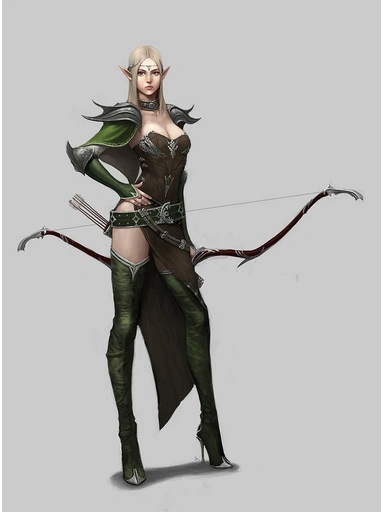

00000001_c257ab95e246b58f.webp


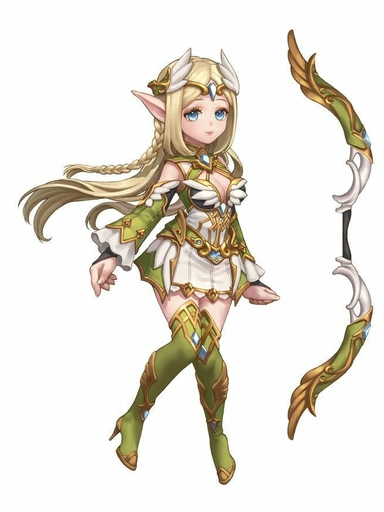

00000002_53ca1e8bac8f3eed.webp


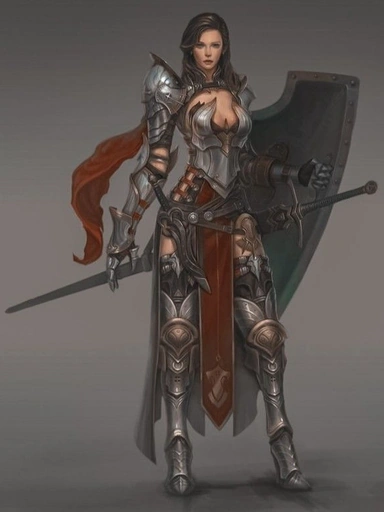

00000003_f107d05e9966bc3e.webp


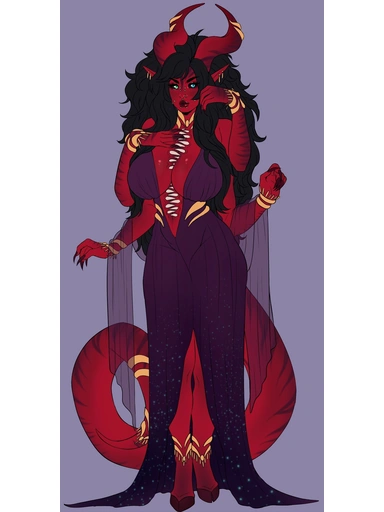

00000004_f444aeab87ac7577.webp


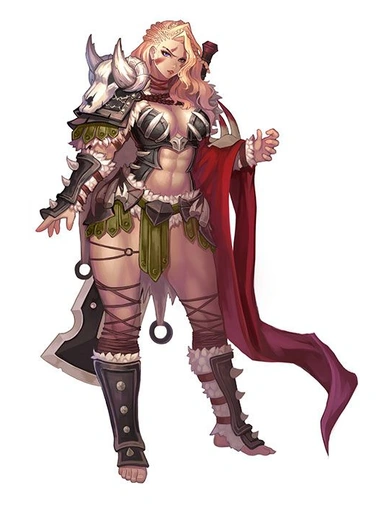

00000005_0bbebc0c29301405.webp


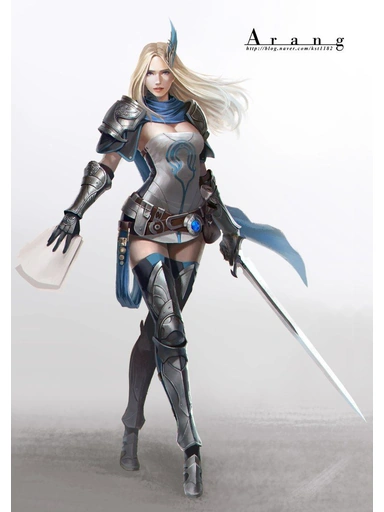

00000006_c798a7b526bb6dfd.webp


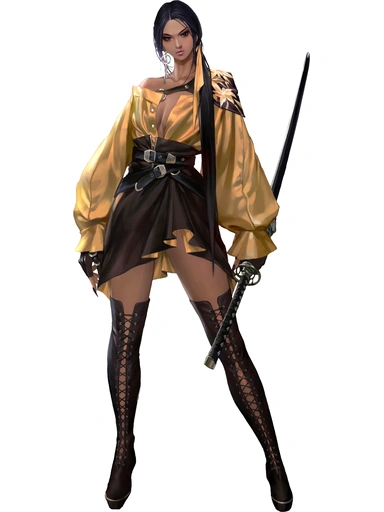

00000007_c3a9573d4a6b1ef9.webp


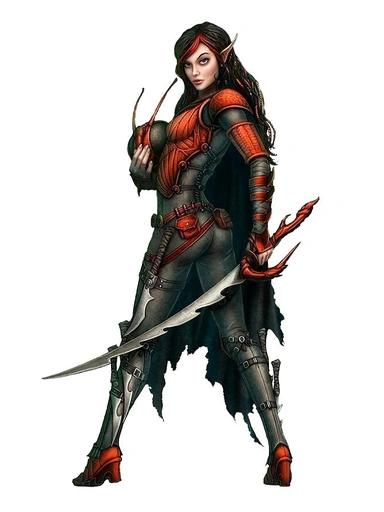

00000008_4dde4c3252e1d1de.webp


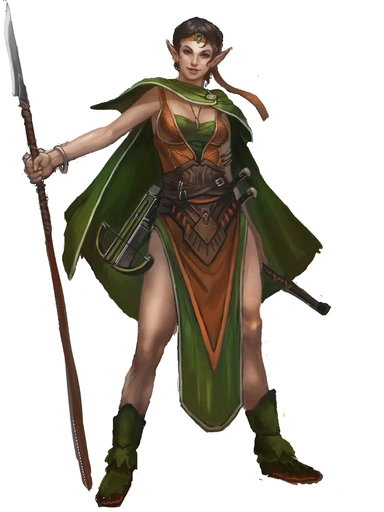

00000009_f9533fd84442f249.webp


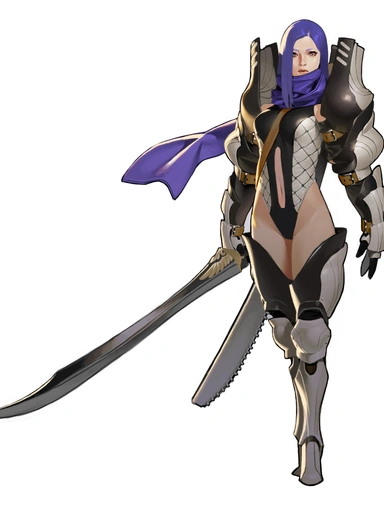

00000010_1a479d01c3b3594b.webp


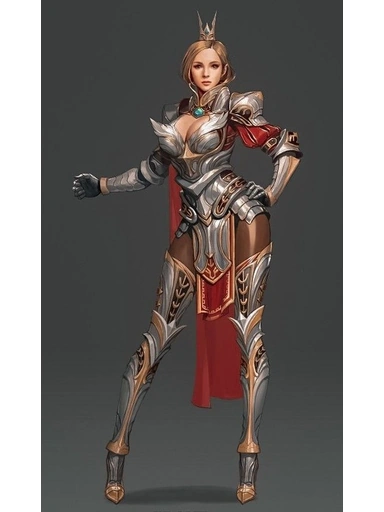

00000011_1ddeb164adb0d348.webp


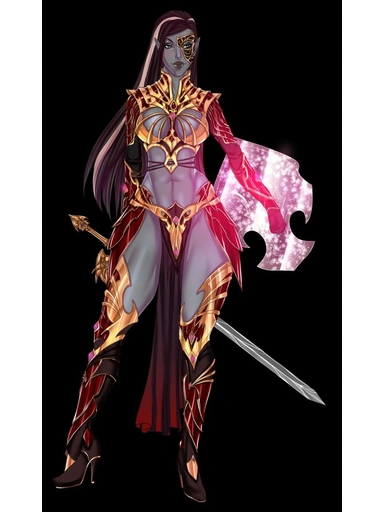

In [14]:
from IPython.display import display

for path in output_files[:12]:
    print(path.name)
    display(Image.open(path))
